In [1]:
import random
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch
import pathlib
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import sampler

In [2]:
# DO NOT CHANGE
data_dir = pathlib.Path('data/')
mnist = datasets.MNIST(data_dir, download=True, train=True)

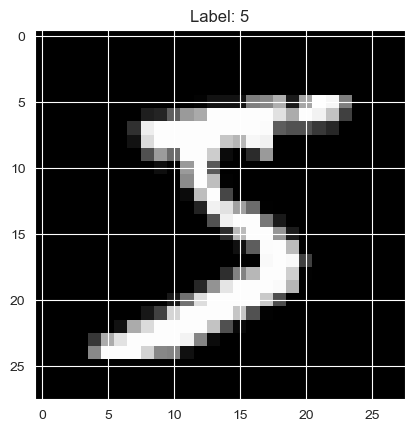

In [3]:
X_sample, y_sample = mnist[0]
# TODO: display the label and the image
plt.imshow(X_sample, cmap='gray')
plt.title(f'Label: {y_sample}')
plt.show()

In [4]:
# TODO: print out the length of the dataset
print(len(mnist))

60000


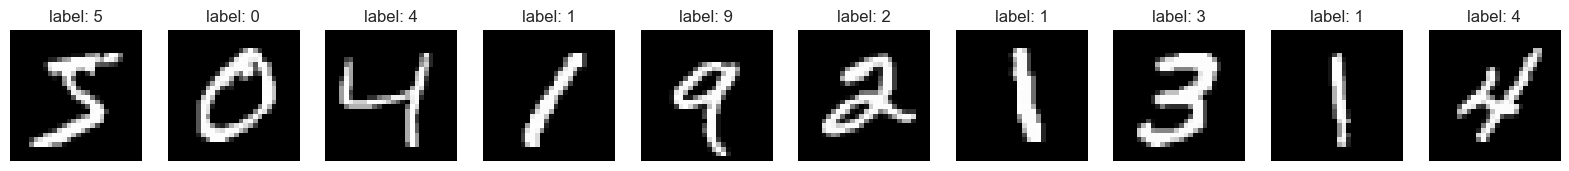

In [5]:
# DO NOT CHANGE
N = 10
fig, axes = plt.subplots(1, N, figsize=(2*N, 2))
X, y = mnist.data, mnist.targets
for ax, image, label in zip(axes.ravel(), X, y):
  ax.set_title("label: {}".format(label))
  ax.axis('off')
  ax.imshow(image.reshape(28,28), cmap='gray') # Remember, images are 28x28

In [6]:
# DO NOT CHANGE
mnist = datasets.MNIST(data_dir, download=True, train=True, transform=transforms.ToTensor())

In [7]:
# DO NOT CHANGE
tmp_dataloader = torch.utils.data.DataLoader(mnist, batch_size=len(mnist), shuffle=True)

In [8]:
 # TODO calculate the mean and standard deviation of MNIST train dataset
mean = mnist.data.float().mean() / 255
std = mnist.data.float().std() / 255
print('mean =',mean)
print('std =', std)

mean = tensor(0.1307)
std = tensor(0.3081)


In [9]:
# DO NOT CHANGE
mnist_transforms = transforms.Compose([transforms.ToTensor(), transforms.Normalize((mean,), (std,))])

In [10]:
# TODO download the dataset for training and testing, with normalization transform
mnist_train = datasets.MNIST(data_dir, train=True, transform=mnist_transforms,download=True)
mnist_test = datasets.MNIST(data_dir, train=False, transform=mnist_transforms,download=True)

In [11]:
print(len(mnist_train), len(mnist_test))

60000 10000


In [12]:
# TODO split the train dataset in mnist_train and mnist_val
train_set, val_set = torch.utils.data.random_split(mnist_train, [54000, 6000], 
                                                   generator=torch.Generator().manual_seed(1))

In [13]:
batch_size = 256

In [14]:
# TODO create dataloader for training, validation and test
train_dataloader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(mnist_test, batch_size=batch_size, shuffle=False)

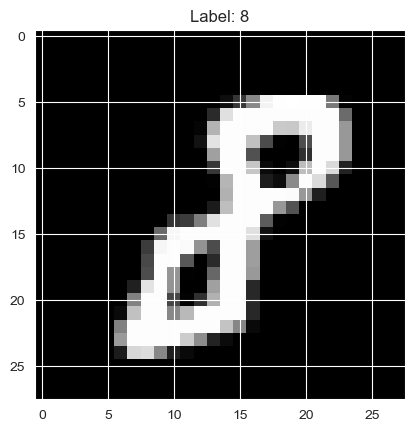

In [39]:
# TODO display an element of the train_dataloader
x, y = next(iter(train_dataloader))
plt.title(f'Label: {y[0]}')
plt.imshow(x[0].squeeze(), cmap="gray")
plt.show()

In [16]:
# TODO display the dimensions of x and y
print(x.shape)
print(y.shape)

torch.Size([256, 1, 28, 28])
torch.Size([256])


In [51]:
epochs = 10
input_dim = 28 * 28
output_dim = 10
lr = 0.001

In [18]:
class LogisticRegression(torch.nn.Module):
    """
    Logistic regression model inherits the torch.nn.Module 
    which is the base class for all neural network modules.
    """
    def __init__(self, input_dim, output_dim):
        """ Initializes internal Module state. """
        super(LogisticRegression, self).__init__()
        # TODO define linear layer for the model
        self.linear = torch.nn.Linear(input_dim, output_dim)


    def forward(self, x):
        """ Defines the computation performed at every call. """
        # What are the dimensions of your input layer?
        # TODO flatten the input to a suitable size for the initial layer
        x = torch.flatten(x, start_dim = 1)
        # TODO run the data through the layer
        outputs = torch.softmax(self.linear(x), dim=1)
        return outputs

In [19]:
# TODO instantiate the model
model = LogisticRegression(input_dim, output_dim)

In [20]:
# TODO put the model in train mode
model.train()

LogisticRegression(
  (linear): Linear(in_features=784, out_features=10, bias=True)
)

In [21]:
# TODO define the loss function
loss_function = torch.nn.CrossEntropyLoss()

In [22]:
# DO NOT CHANGE
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

In [52]:
# TODO fill in the missing lines
for epoch in range(epochs):
    for i, (images, labels) in enumerate(train_dataloader):
        # delete the gradients from last training iteration
        optimizer.zero_grad()

        # Forward pass: get predictions
        y_pred =  model(images)

        # Compute loss
        loss = loss_function(y_pred, labels)

        # Backward pass -> calculate gradients, update weights
        loss.backward()
        optimizer.step()

In [56]:
# TODO get a random element of the test dataloader
x, y = next(iter(train_dataloader))
x = x[0]
y = y[0]
# TODO set model in eval mode
model.eval()
# no automatic gradient update needed in evaluation
with torch.no_grad():
    # TODO make a prediction
    y_pred = model(x)

# print predicted label and given label
print("predicted label: ", y_pred.argmax())
print("given label: ", y)

predicted label:  tensor(7)
given label:  tensor(7)
